In [74]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [75]:
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32
NUM_EPOCHS = 30
DATASET_PATH = "dataset/dogs-vs-cats-split"

In [76]:
if not Path(DATASET_PATH).exists():
    raise SystemExit("Данные отсутствуют")

In [77]:
def preprocess_vgg(img):
    # VGG16 ожидает данные в формате BGR, а не RGB
    img = tf.keras.applications.vgg16.preprocess_input(img)
    return img

In [78]:
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_vgg,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)

# Генератор для валидационных и тестовых данных
val_test_datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_vgg
)

In [79]:
train_generator = train_datagen.flow_from_directory(
    f"{DATASET_PATH}/train",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
    f"{DATASET_PATH}/val",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

test_generator = val_test_datagen.flow_from_directory(
    f"{DATASET_PATH}/test",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"Классы: {train_generator.class_indices}")
print(f"Размер тренировочной выборки: {train_generator.samples}")
print(f"Размер валидационной выборки: {validation_generator.samples}")
print(f"Размер тестовой выборки: {test_generator.samples}")

Found 2999 images belonging to 2 classes.
Found 1020 images belonging to 2 classes.
Found 18476 images belonging to 2 classes.
Классы: {'cats': 0, 'dogs': 1}
Размер тренировочной выборки: 2999
Размер валидационной выборки: 1020
Размер тестовой выборки: 18476


In [80]:
base_model = keras.applications.VGG16(
    weights='imagenet',
    include_top=False,  # Не включаем верхние слои (классификатор)
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

print(f"Базовая модель VGG16 загружена")
print(f"Количество слоев в VGG16: {len(base_model.layers)}")

Базовая модель VGG16 загружена
Количество слоев в VGG16: 19


In [81]:
base_model.trainable = False  # ЗАМОРАЖИВАЕМ ВСЕ СЛОИ VGG16
print("Проверка заморозки слоев:")
for layer in base_model.layers:
    print(f"  {layer.name}: trainable = {layer.trainable}")

Проверка заморозки слоев:
  input_layer_15: trainable = False
  block1_conv1: trainable = False
  block1_conv2: trainable = False
  block1_pool: trainable = False
  block2_conv1: trainable = False
  block2_conv2: trainable = False
  block2_pool: trainable = False
  block3_conv1: trainable = False
  block3_conv2: trainable = False
  block3_conv3: trainable = False
  block3_pool: trainable = False
  block4_conv1: trainable = False
  block4_conv2: trainable = False
  block4_conv3: trainable = False
  block4_pool: trainable = False
  block5_conv1: trainable = False
  block5_conv2: trainable = False
  block5_conv3: trainable = False
  block5_pool: trainable = False


In [82]:
def create_vgg16_with_custom_classifier():
    """
    Создает модель VGG16 с замороженной основой и
    классификатором из этапа 2
    """
    model = keras.Sequential([
        # 1. Базовая модель VGG16 (ЗАМОРОЖЕННАЯ)
        base_model,

        # 2. Сверточная часть из этапа 2 (повторяем архитектуру)
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2, padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2, padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2, padding='same'),

        # 3. Полносвязная часть из этапа 2
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(512, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # Бинарная классификация
    ])

    return model

In [83]:
def create_vgg16_simple_classifier():
    """
    Создает модель VGG16 с замороженной основой и
    простым классификатором
    """
    model = keras.Sequential([
        # 1. Базовая модель VGG16 (ЗАМОРОЖЕННАЯ)
        base_model,

        # 2. Глобальное усреднение вместо Flatten
        layers.GlobalAveragePooling2D(),

        # 3. Полносвязные слои
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    return model

In [84]:
model = create_vgg16_with_custom_classifier()

print("Архитектура полной модели:")
model.summary()

model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Архитектура полной модели:


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 4, 4, 32)       │       147,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 2, 2, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 1, 1, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,021,089 (57.30 MB)

 Trainable params: 306,401 (1.17 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [85]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='models/best_vgg16_frozen.h5',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.TensorBoard(
        log_dir='logs/vgg16_frozen',
        histogram_freq=1
    )
]

history = model.fit(
    train_generator,
    epochs=NUM_EPOCHS,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)

model.save('models/final_vgg16_frozen.h5')

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.6849 - loss: 0.5693
Epoch 1: val_accuracy improved from None to 0.93824, saving model to models/best_vgg16_frozen.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 87s 922ms/step - accuracy: 0.8016 - loss: 0.3939 - val_accuracy: 0.9382 - val_loss: 0.1305
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.9285 - loss: 0.1788
Epoch 2: val_accuracy improved from 0.93824 to 0.95490, saving model to models/best_vgg16_frozen.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 86s 921ms/step - accuracy: 0.9333 - loss: 0.1692 - val_accuracy: 0.9549 - val_loss: 0.1180
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.9421 - loss: 0.1451
Epoch 3: val_accuracy improved from 0.95490 to 0.95980, saving model to models/best_vgg16_frozen.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 85s 909ms/step - accuracy: 0.9460 - loss: 0.1480 - val_accuracy: 0.9598 - val_loss: 0.1172
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.9521 - loss: 0.1230
Epoch 4: val_accuracy did not improve from 0.95980
94/94 ━━━━━━━━━━━━━━━━━━━━ 86s 916ms/step - accuracy: 0.9543 - loss: 0.1179 - val_accuracy: 0.9382 - val_loss: 0.1763
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.9562 - loss: 0.1199
Epoch 5: val_accuracy did not improve from 0.95980
94/94 ━━━━━━━━━━━━━━━━━━━━ 85s 911ms/step - accuracy: 0.9533 - loss: 0.1260 - val_accuracy: 0.9500 - val_loss: 0.1306
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.9599 - loss: 0.1087
Epoch 6: val_accuracy improved from 0.95980 to 0.96176, saving model to models/best_vgg16_frozen.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 85s 903ms/step - accuracy: 0.9600 - loss: 0.1032 - val_accuracy: 0.9618 - val_loss: 0.1242
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.9603 - loss: 0.1178
Epoch 7: val_accuracy did not improve from 0.96176
94/94 ━━━━━━━━━━━━━━━━━━━━ 86s 921ms/step - accuracy: 0.9580 - loss: 0.1100 - val_accuracy: 0.9588 - val_loss: 0.1147
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.9619 - loss: 0.0974
Epoch 8: val_accuracy did not improve from 0.96176
94/94 ━━━━━━━━━━━━━━━━━━━━ 84s 898ms/step - accuracy: 0.9680 - loss: 0.0918 - val_accuracy: 0.9618 - val_loss: 0.1270
Epoch 9/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.9613 - loss: 0.1051
Epoch 9: val_accuracy did not improve from 0.96176
94/94 ━━━━━━━━━━━━━━━━━━━━ 86s 922ms/step - accuracy: 0.9630 - loss: 0.1007 - val_accuracy: 0.9490 - val_loss: 0.1443
Epoch 10/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 712ms/step - accuracy: 0.9709 - loss: 0.0804
Epoch 10: val_accuracy improve

94/94 ━━━━━━━━━━━━━━━━━━━━ 89s 946ms/step - accuracy: 0.9677 - loss: 0.0862 - val_accuracy: 0.9637 - val_loss: 0.1203
Epoch 11/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.9731 - loss: 0.0730
Epoch 11: val_accuracy did not improve from 0.96373
94/94 ━━━━━━━━━━━━━━━━━━━━ 87s 922ms/step - accuracy: 0.9703 - loss: 0.0834 - val_accuracy: 0.9559 - val_loss: 0.1171
Epoch 12/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.9694 - loss: 0.0855
Epoch 12: val_accuracy did not improve from 0.96373
94/94 ━━━━━━━━━━━━━━━━━━━━ 87s 933ms/step - accuracy: 0.9703 - loss: 0.0828 - val_accuracy: 0.9618 - val_loss: 0.1182
Epoch 13/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 710ms/step - accuracy: 0.9773 - loss: 0.0667
Epoch 13: val_accuracy did not improve from 0.96373
94/94 ━━━━━━━━━━━━━━━━━━━━ 92s 977ms/step - accuracy: 0.9753 - loss: 0.0731 - val_accuracy: 0.9608 - val_loss: 0.1161
Epoch 14/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - accuracy: 0.9787 - loss: 0.0643
Epoch 14: val_accuracy i

94/94 ━━━━━━━━━━━━━━━━━━━━ 85s 905ms/step - accuracy: 0.9740 - loss: 0.0787 - val_accuracy: 0.9647 - val_loss: 0.1146
Epoch 15/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.9710 - loss: 0.0703
Epoch 15: val_accuracy did not improve from 0.96471
94/94 ━━━━━━━━━━━━━━━━━━━━ 84s 899ms/step - accuracy: 0.9783 - loss: 0.0599 - val_accuracy: 0.9578 - val_loss: 0.1412
Epoch 16/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.9750 - loss: 0.0791
Epoch 16: val_accuracy did not improve from 0.96471
94/94 ━━━━━━━━━━━━━━━━━━━━ 84s 895ms/step - accuracy: 0.9723 - loss: 0.0851 - val_accuracy: 0.9627 - val_loss: 0.1199
Epoch 17/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - accuracy: 0.9750 - loss: 0.0773
Epoch 17: val_accuracy did not improve from 0.96471
94/94 ━━━━━━━━━━━━━━━━━━━━ 85s 907ms/step - accuracy: 0.9737 - loss: 0.0776 - val_accuracy: 0.9637 - val_loss: 0.1127
Epoch 18/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - accuracy: 0.9785 - loss: 0.0585
Epoch 18: val_accuracy i

94/94 ━━━━━━━━━━━━━━━━━━━━ 88s 935ms/step - accuracy: 0.9770 - loss: 0.0594 - val_accuracy: 0.9667 - val_loss: 0.1261
Epoch 19/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.9775 - loss: 0.0751
Epoch 19: val_accuracy did not improve from 0.96667
94/94 ━━━━━━━━━━━━━━━━━━━━ 85s 901ms/step - accuracy: 0.9743 - loss: 0.0698 - val_accuracy: 0.9569 - val_loss: 0.1445
Epoch 20/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.9794 - loss: 0.0521
Epoch 20: val_accuracy did not improve from 0.96667
94/94 ━━━━━━━━━━━━━━━━━━━━ 87s 933ms/step - accuracy: 0.9777 - loss: 0.0572 - val_accuracy: 0.9618 - val_loss: 0.1322
Epoch 21/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.9796 - loss: 0.0519
Epoch 21: val_accuracy did not improve from 0.96667
94/94 ━━━━━━━━━━━━━━━━━━━━ 92s 976ms/step - accuracy: 0.9793 - loss: 0.0551 - val_accuracy: 0.9647 - val_loss: 0.1395
Epoch 22/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.9754 - loss: 0.0718
Epoch 22: val_accuracy d

94/94 ━━━━━━━━━━━━━━━━━━━━ 86s 915ms/step - accuracy: 0.9790 - loss: 0.0566 - val_accuracy: 0.9686 - val_loss: 0.1352
Epoch 24/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.9787 - loss: 0.0610
Epoch 24: val_accuracy did not improve from 0.96863
94/94 ━━━━━━━━━━━━━━━━━━━━ 87s 930ms/step - accuracy: 0.9797 - loss: 0.0631 - val_accuracy: 0.9637 - val_loss: 0.1326
Epoch 25/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.9871 - loss: 0.0375
Epoch 25: val_accuracy did not improve from 0.96863
94/94 ━━━━━━━━━━━━━━━━━━━━ 86s 921ms/step - accuracy: 0.9853 - loss: 0.0452 - val_accuracy: 0.9667 - val_loss: 0.1421
Epoch 26/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.9781 - loss: 0.0569
Epoch 26: val_accuracy did not improve from 0.96863
94/94 ━━━━━━━━━━━━━━━━━━━━ 87s 924ms/step - accuracy: 0.9813 - loss: 0.0524 - val_accuracy: 0.9657 - val_loss: 0.1623
Epoch 27/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - accuracy: 0.9812 - loss: 0.0541
Epoch 27: val_accuracy d

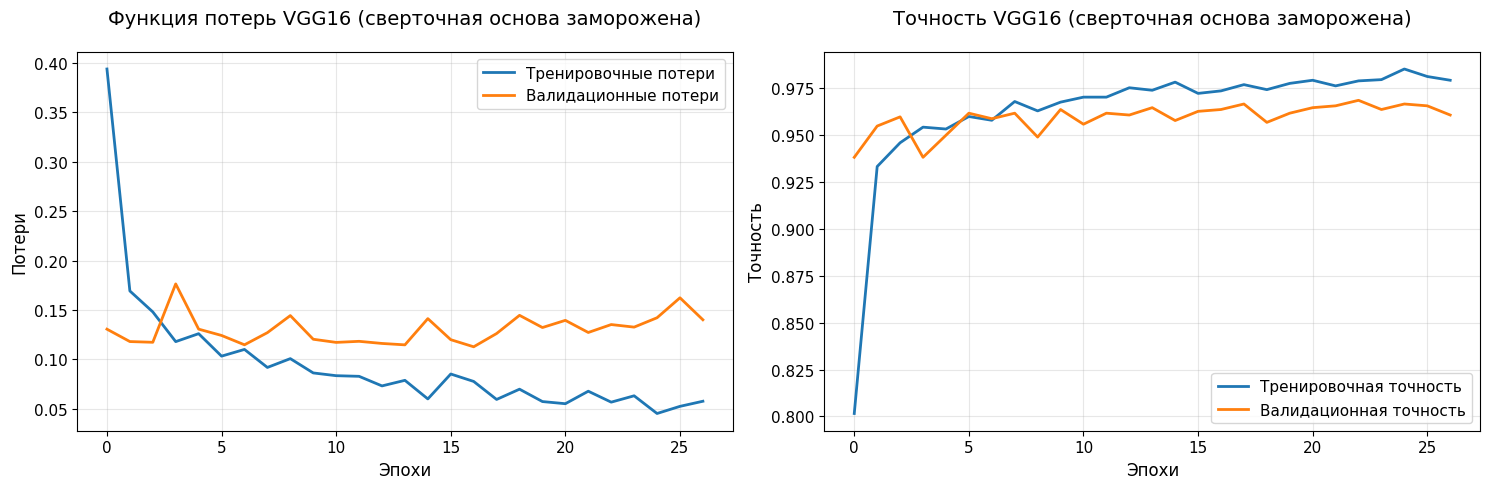

In [87]:
plt.figure(figsize=(15, 5))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Тренировочные потери', linewidth=2)
plt.plot(history.history['val_loss'], label='Валидационные потери', linewidth=2)
plt.title('Функция потерь VGG16 (сверточная основа заморожена)', fontsize=14, pad=20)
plt.xlabel('Эпохи', fontsize=12)
plt.ylabel('Потери', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# График точности
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Тренировочная точность', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Валидационная точность', linewidth=2)
plt.title('Точность VGG16 (сверточная основа заморожена)', fontsize=14, pad=20)
plt.xlabel('Эпохи', fontsize=12)
plt.ylabel('Точность', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

In [88]:
best_model = keras.models.load_model('models/best_vgg16_frozen.h5')

test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=0)
print(f"Результаты на тестовом наборе:")
print(f"  Потери: {test_loss:.4f}")
print(f"  Точность: {test_accuracy:.4f}")
print(f"  Точность в процентах: {test_accuracy * 100:.2f}%")

Результаты на тестовом наборе:
  Потери: 0.1076
  Точность: 0.9720
  Точность в процентах: 97.20%


FileNotFoundError: [Errno 2] No such file or directory: 'results/vgg16_frozen_predictions.png'

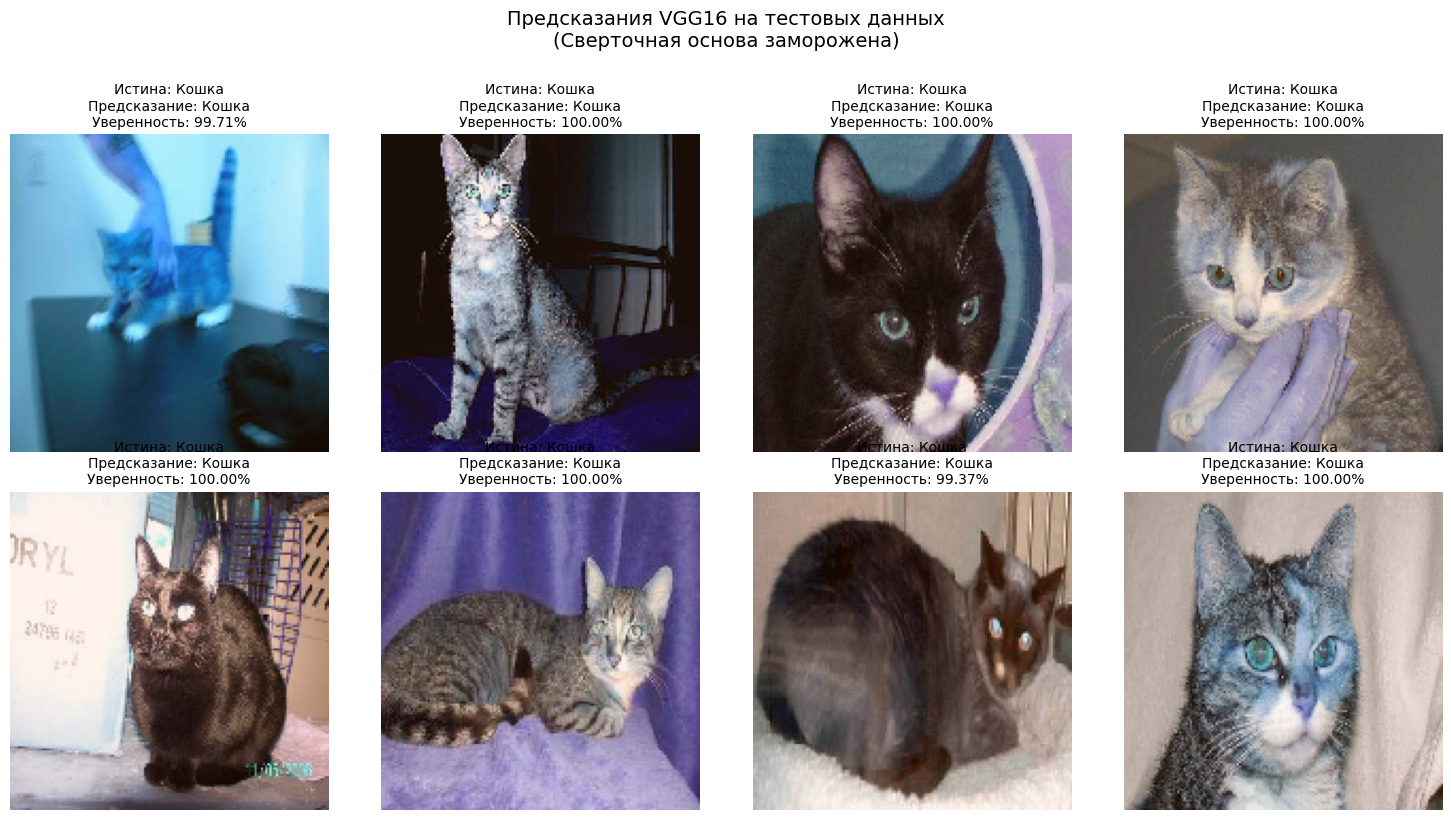

In [89]:
test_images, test_labels = next(test_generator)
num_examples = min(8, BATCH_SIZE)

plt.figure(figsize=(15, 8))
for i in range(num_examples):
    image = test_images[i]
    true_label = test_labels[i]
    true_class = "Кошка" if true_label == 0 else "Собака"

    img_for_pred = np.expand_dims(image, axis=0)
    prediction = best_model.predict(img_for_pred, verbose=0)[0][0]

    predicted_class = "Кошка" if prediction < 0.5 else "Собака"
    confidence = prediction if prediction >= 0.5 else 1 - prediction

    plt.subplot(2, 4, i + 1)
    img_display = image.copy()
    img_display = img_display - img_display.min()
    img_display = img_display / img_display.max()

    plt.imshow(img_display)
    plt.title(f'Истина: {true_class}\nПредсказание: {predicted_class}\nУверенность: {confidence:.2%}',
              fontsize=10)
    plt.axis('off')

    is_correct = (true_class == predicted_class)
    frame_color = 'green' if is_correct else 'red'
    plt.gca().spines['bottom'].set_color(frame_color)
    plt.gca().spines['top'].set_color(frame_color)
    plt.gca().spines['left'].set_color(frame_color)
    plt.gca().spines['right'].set_color(frame_color)
    plt.gca().spines['bottom'].set_linewidth(3)
    plt.gca().spines['top'].set_linewidth(3)
    plt.gca().spines['left'].set_linewidth(3)
    plt.gca().spines['right'].set_linewidth(3)

plt.suptitle('Предсказания VGG16 на тестовых данных\n(Сверточная основа заморожена)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()